# 🤖 Fake vs Real News — Transformer Model
### Same pipeline as Model 1 (CNN+BiLSTM) — only architecture replaced with Transformer
**Decisions locked:**
- ✅ Same Tokenizer (Keras, 20k vocab, lemmatized input)
- ✅ Learned Positional Encoding (domain-specific, MAX_LEN=788)
- ✅ 4 Attention Heads (balanced for ~55k dataset)


In [1]:
import os
os.listdir('/kaggle/input/datasets/unknownx45/fakevsreal/')

['WELFake_Dataset.csv']

In [2]:
import pandas as pd

path = '/kaggle/input/datasets/unknownx45/fakevsreal/WELFake_Dataset.csv'

bad_lines = []
def collect_bad_lines(bad_line_list):
    bad_lines.append(bad_line_list)
    return None

df = pd.read_csv(path, on_bad_lines='skip', engine='python')
print(f"Successfully loaded {len(df)} rows.")


Successfully loaded 72154 rows.


## 🔹 Data Cleaning

In [3]:
# Combine title + text
df['content'] = df['title'] + ' ' + df['text']

# Drop nulls
df = df.dropna(subset=['content', 'label'])

print("Missing values:\n", df.isnull().sum())
print("Shape:", df.shape)


Missing values:
 Unnamed: 0    0
title         0
text          0
label         0
content       0
dtype: int64
Shape: (71537, 5)


In [4]:
import sys
!{sys.executable} -m pip install langdetect -q

from langdetect import detect

def robust_lang_check(content):
    try:
        return detect(content[:500])
    except:
        return "unknown"

df['detected_lang'] = df['content'].apply(robust_lang_check)
df = df[df['detected_lang'] == 'en'].copy()
print(df['detected_lang'].value_counts())
print("Shape after language filter:", df.shape)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 21.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
detected_lang
en    71011
Name: count, dtype: int64
Shape after language filter: (71011, 6)


In [5]:
# Keep only required columns
df = df[['content', 'label', 'detected_lang']]
df.reset_index(drop=True, inplace=True)

# Fix corrupted labels
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

print("Label distribution:\n", df['label'].value_counts())
print("Label dtype:", df['label'].dtype)


Label distribution:
 label
1    35983
0    35027
Name: count, dtype: int64
Label dtype: int64


In [6]:
# Remove duplicate content+label pairs
df = df.drop_duplicates(subset=['content', 'label'])

# Remove conflicting content (same content, different labels)
conflicting = df.groupby('content')['label'].nunique()
conflicting = conflicting[conflicting > 1].index
df = df[~df['content'].isin(conflicting)]
df.reset_index(drop=True, inplace=True)

print("Shape after deduplication:", df.shape)
print("Unique content:", df['content'].nunique())


Shape after deduplication: (62610, 3)
Unique content: 62610


## 🔹 NLP Preprocessing (identical to Model 1)

In [7]:
'''
import re
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# Preserve negation words — critical for fake news detection
stop_words = set(stopwords.words('english'))
negation_words = {'not', 'no', 'nor', 'never', 'neither', 'nobody', 'nothing', 'nowhere'}
stop_words = stop_words - negation_words

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('V'):   return wordnet.VERB
    elif tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('R'): return wordnet.ADV
    else:                     return wordnet.NOUN

def preprocess_text(text):
    text = str(text)
    text = text.replace('\n', ' ').replace('\r', ' ')
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [w for w in words if w not in stop_words]
    pos_tags = pos_tag(words)
    words = [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tags]
    return ' '.join(words)

print("Preprocessing pipeline ready.")
print(f"Stopwords: {len(stop_words)} | Negation words preserved: {negation_words}")
'''

<>:31: SyntaxWarning: invalid escape sequence '\S'
<>:31: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_23/4110605650.py:31: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub(r'http\S+|www\S+', '', text)


'\nimport re\nimport nltk\nfrom nltk.corpus import stopwords, wordnet\nfrom nltk.stem import WordNetLemmatizer\nfrom nltk import pos_tag\n\nnltk.download(\'stopwords\')\nnltk.download(\'wordnet\')\nnltk.download(\'omw-1.4\')\nnltk.download(\'averaged_perceptron_tagger\')\nnltk.download(\'averaged_perceptron_tagger_eng\')\n\n# Preserve negation words — critical for fake news detection\nstop_words = set(stopwords.words(\'english\'))\nnegation_words = {\'not\', \'no\', \'nor\', \'never\', \'neither\', \'nobody\', \'nothing\', \'nowhere\'}\nstop_words = stop_words - negation_words\n\nlemmatizer = WordNetLemmatizer()\n\ndef get_wordnet_pos(tag):\n    if tag.startswith(\'V\'):   return wordnet.VERB\n    elif tag.startswith(\'J\'): return wordnet.ADJ\n    elif tag.startswith(\'R\'): return wordnet.ADV\n    else:                     return wordnet.NOUN\n\ndef preprocess_text(text):\n    text = str(text)\n    text = text.replace(\'\n\', \' \').replace(\'\r\', \' \')\n    text = text.lower()\n  

In [8]:
# ================================
# ADVANCED PREPROCESSING PIPELINE
# For Fake News Detection
# ================================

import re
import nltk

from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# ================================
# DOWNLOAD REQUIRED NLTK FILES
# ================================

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# OLD VERSION
nltk.download('averaged_perceptron_tagger')

# NEW VERSION REQUIRED
nltk.download('averaged_perceptron_tagger_eng')

# ================================
# INITIALIZE LEMMATIZER
# ================================

lemmatizer = WordNetLemmatizer()

# ================================
# OPTIONAL:
# KEEP IMPORTANT NEGATION WORDS
# (Only needed if you use stopword removal)
# ================================

stop_words = set(stopwords.words('english'))

negation_words = {
    'not', 'no', 'nor', 'never',
    'neither', 'nobody', 'nothing', 'nowhere'
}

stop_words = stop_words - negation_words

# ================================
# POS TAG CONVERTER
# ================================

def get_wordnet_pos(tag):

    if tag.startswith('J'):
        return wordnet.ADJ

    elif tag.startswith('V'):
        return wordnet.VERB

    elif tag.startswith('R'):
        return wordnet.ADV

    else:
        return wordnet.NOUN


# ================================
# MAIN PREPROCESS FUNCTION
# ================================

def preprocess_text(text):

    # Convert to string
    text = str(text)

    # Remove line breaks
    text = text.replace('\n', ' ').replace('\r', ' ')

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Keep:
    # alphabets
    # numbers
    # punctuation useful for fake news detection
    text = re.sub(r"[^a-zA-Z0-9!?.,'\s]", '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # =====================================
    # OPTIONAL STOPWORD REMOVAL
    # =====================================
    # COMMENT THIS BLOCK if you want
    # to preserve sentence structure fully
    # =====================================

    # words = [w for w in words if w not in stop_words]

    # POS tagging
    pos_tags = pos_tag(words)

    # Lemmatization with POS tagging
    words = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in pos_tags
    ]

    # Join back
    text = ' '.join(words)

    return text


# ================================
# TEST EXAMPLES
# ================================

samples = [

    "BREAKING!!! Trump says this is NOT true!!!",

    "Reuters - U.S. President Donald Trump met officials in Washington.",

    "Scientists discover a new method for cancer treatment.",

    "Obama secretly supports aliens??? Read more NOW!!!"

]

# ================================
# RUN TEST
# ================================

for text in samples:

    cleaned = preprocess_text(text)

    print("=" * 70)
    print("BEFORE :", text)
    print("AFTER  :", cleaned)
    print()


print("=" * 70)
print("Preprocessing pipeline ready ✅")
print("Negation words preserved :", negation_words)

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


BEFORE : BREAKING!!! Trump says this is NOT true!!!
AFTER  : breaking!!! trump say this be not true!!!

BEFORE : Reuters - U.S. President Donald Trump met officials in Washington.
AFTER  : reuters u.s. president donald trump meet official in washington.

BEFORE : Scientists discover a new method for cancer treatment.
AFTER  : scientist discover a new method for cancer treatment.

BEFORE : Obama secretly supports aliens??? Read more NOW!!!
AFTER  : obama secretly support aliens??? read more now!!!

Preprocessing pipeline ready ✅
Negation words preserved : {'nowhere', 'neither', 'nor', 'nothing', 'no', 'never', 'not', 'nobody'}


In [9]:
df['clean_title'] = df['content'].apply(preprocess_text)
print(df[['content', 'clean_title']].head(5))

                                             content  \
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
2  Bobby Jindal, raised Hindu, uses story of Chri...   
3  SATAN 2: Russia unvelis an image of its terrif...   
4  About Time! Christian Group Sues Amazon and SP...   

                                         clean_title  
0  law enforcement on high alert follow threat ag...  
1  unbelievable! obamas attorney general say most...  
2  bobby jindal, raise hindu, us story of christi...  
3  satan 2 russia unvelis an image of it terrify ...  
4  about time! christian group sue amazon and spl...  


In [10]:
# Pick a few rows and manually check
sample = df[['clean_title', 'label']].sample(10, random_state=1)
for _, row in sample.iterrows():
    print(f"Label {row['label']} | {row['clean_title'][:120]}")
    print()

Label 0 | israel welcome u.s. airstrikes in syria, will keep to sideline jerusalem reuters israeli leader welcome the u.s. airstri

Label 1 | clinton policy on syria will lead to ww3 say trump clinton policy on syria will lead to ww3 say trump by iwb october 26,

Label 0 | watch adam pacman jones kick reporter ask about his arrest out of interview breitbart cincinnati bengal cornerback adam 

Label 0 | after 225 billion in deal last year, china rein in overseas investment the new york time beijing china struck 225 billio

Label 1 | market collapse a donald trump be project to win market collapse a donald trump be project to win 09.11.2016 source prav

Label 0 | samsung to recall 2.5 million galaxy note 7 over battery fire the new york time hong kong a ubiquitous source of power i

Label 0 | u.s. militia girds for trouble a presidential election near jackson, ga. reuters down a georgia country road, camouflage

Label 1 | knownothing trump reverse yet another position on foreign policy d

In [11]:
# ── Sanity check — 10 random samples ─────────────────────────────────
sample = df[['content', 'clean_title', 'label']].sample(10, random_state=42)

print("=" * 80)
for _, row in sample.iterrows():
    label = "REAL" if row['label'] == 0 else "FAKE"
    print(f"LABEL  : {label}")
    print(f"BEFORE : {row['content'][:150]}")
    print(f"AFTER  : {row['clean_title'][:150]}")
    print("-" * 80)

LABEL  : FAKE
BEFORE :  Eric Trump Just Asked The Labor Department To Let Him Hire Foreign Workers AGAIN If any other American company did this, Donald Trump would be attack
AFTER  : eric trump just ask the labor department to let him hire foreign worker again if any other american company do this, donald trump would be attack them
--------------------------------------------------------------------------------
LABEL  : REAL
BEFORE : Thousands of Romanians mourn former king Michael BUCHAREST (Reuters) - Thousands of Romanians lined the streets of Bucharest on Saturday for the funer
AFTER  : thousand of romanian mourn former king michael bucharest reuters thousand of romanian line the street of bucharest on saturday for the funeral of the 
--------------------------------------------------------------------------------
LABEL  : FAKE
BEFORE : Those Who Thoughtlessly Disbelieve “Conspiracy Theories” Need To Read This Those Who Thoughtlessly Disbelieve “Conspiracy Theories” Need To Read Th

## 🔹 Balancing & Splitting

In [12]:
import re, os, random, numpy as np, tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Balance dataset
min_count = df['label'].value_counts().min()
df_balanced = df.groupby('label').sample(n=min_count, random_state=SEED)
print("Balanced label distribution:\n", df_balanced['label'].value_counts())

X = df_balanced['clean_title'].values
y = df_balanced['label'].values


2026-05-17 11:31:36.010668: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779017496.192734      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779017496.245089      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779017496.676526      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779017496.676554      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779017496.676558      23 computation_placer.cc:177] computation placer alr

Balanced label distribution:
 label
0    27820
1    27820
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

# 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train : {len(X_train):,} | Fake: {(y_train==0).sum():,} Real: {(y_train==1).sum():,}')
print(f'Val   : {len(X_val):,}  | Fake: {(y_val==0).sum():,}  Real: {(y_val==1).sum():,}')
print(f'Test  : {len(X_test):,}  | Fake: {(y_test==0).sum():,}  Real: {(y_test==1).sum():,}')


Train : 38,948 | Fake: 19,474 Real: 19,474
Val   : 8,346  | Fake: 4,173  Real: 4,173
Test  : 8,346  | Fake: 4,173  Real: 4,173


## 🔹 Tokenization (identical to Model 1)

In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

print(f'Vocabulary size (unique words): {len(tokenizer.word_index):,}')
print(f'Capped at: {vocab_size:,}')


Vocabulary size (unique words): 196,091
Capped at: 20,000


In [15]:
# Text → sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Remove empty sequences
def filter_empty(seqs, labels):
    non_empty   = [(s, l) for s, l in zip(seqs, labels) if len(s) > 0]
    seqs_out    = [x[0] for x in non_empty]
    labels_out  = np.array([x[1] for x in non_empty])
    return seqs_out, labels_out

X_train_seq, y_train = filter_empty(X_train_seq, y_train)
X_val_seq,   y_val   = filter_empty(X_val_seq,   y_val)
X_test_seq,  y_test  = filter_empty(X_test_seq,  y_test)

print(f'After empty-filter — Train: {len(X_train_seq):,} Val: {len(X_val_seq):,} Test: {len(X_test_seq):,}')


After empty-filter — Train: 38,948 Val: 8,346 Test: 8,346


In [16]:
# MAX_LEN = 95th percentile (same logic as Model 1)
seq_lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(seq_lengths, 95))
print(f'MAX_LEN = {MAX_LEN}')

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'X_train_pad : {X_train_pad.shape}')
print(f'X_val_pad   : {X_val_pad.shape}')
print(f'X_test_pad  : {X_test_pad.shape}')


MAX_LEN = 1401
X_train_pad : (38948, 1401)
X_val_pad   : (8346, 1401)
X_test_pad  : (8346, 1401)


## 🔹 Transformer Architecture
### Replaces CNN+BiLSTM — everything else stays identical

```
Input Tokens
     │
Embedding (dim=64) + Learned Positional Encoding
     │
     ├─── PATH A: Multi-Head Self-Attention (4 heads) → captures global meaning
     │              ↓
     │         Add & LayerNorm
     │
     └─── PATH B: Feed Forward Network (64→128→64) → captures local patterns
                   ↓
              Add & LayerNorm
     │
  GlobalAveragePooling
     │
  Dropout(0.4)
     │
  Dense(64, relu)
     │
  Dropout(0.3)
     │
  Dense(1, sigmoid) → FAKE / REAL
```


In [17]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Dense, Dropout,
    LayerNormalization, GlobalAveragePooling1D,
    MultiHeadAttention, Add, Layer
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# ── Positional Encoding as a proper Keras Layer ───────────────────────
# This fixes the shape mismatch on GPU (Tesla T4)
class LearnedPositionalEncoding(Layer):
    def __init__(self, max_len, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.max_len   = max_len
        self.embed_dim = embed_dim
        self.pos_embed = Embedding(input_dim=max_len, output_dim=embed_dim)

    def call(self, x):
        # x shape: (batch_size, seq_len, embed_dim)
        seq_len   = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        pos_enc   = self.pos_embed(positions)   # (seq_len, embed_dim)
        return x + pos_enc                       # broadcasting over batch ✅

    def get_config(self):
        config = super().get_config()
        config.update({'max_len': self.max_len, 'embed_dim': self.embed_dim})
        return config

# ── Config ────────────────────────────────────────────────────────────
actual_vocab_size = min(vocab_size, len(tokenizer.word_index) + 1)
EMB_DIM      = 64
NUM_HEADS    = 4
FFN_DIM      = 128
DROPOUT_RATE = 0.3

# ── Build Model ───────────────────────────────────────────────────────
inp = Input(shape=(MAX_LEN,), name='input_tokens')

# Word embedding
x = Embedding(
    input_dim=actual_vocab_size,
    output_dim=EMB_DIM,
    name='word_embedding'
)(inp)                                      # (batch, MAX_LEN, EMB_DIM)

# Learned positional encoding — now a proper layer, GPU safe ✅
x = LearnedPositionalEncoding(MAX_LEN, EMB_DIM, name='pos_encoding')(x)
x = Dropout(DROPOUT_RATE, name='embedding_dropout')(x)

# Multi-Head Self-Attention
attn_output = MultiHeadAttention(
    num_heads=NUM_HEADS,
    key_dim=EMB_DIM // NUM_HEADS,
    dropout=DROPOUT_RATE,
    name='multi_head_attention'
)(x, x)
attn_output = Add(name='attention_residual')([x, attn_output])
attn_output = LayerNormalization(epsilon=1e-6, name='attention_norm')(attn_output)

# Feed Forward Network
ffn_output = Dense(FFN_DIM, activation='relu',
                   kernel_regularizer=l2(0.001),
                   name='ffn_expand')(attn_output)
ffn_output = Dropout(DROPOUT_RATE)(ffn_output)
ffn_output = Dense(EMB_DIM, kernel_regularizer=l2(0.001),
                   name='ffn_contract')(ffn_output)
ffn_output = Add(name='ffn_residual')([attn_output, ffn_output])
ffn_output = LayerNormalization(epsilon=1e-6, name='ffn_norm')(ffn_output)

# Pooling + Classification
pooled = GlobalAveragePooling1D(name='global_avg_pool')(ffn_output)
x = Dropout(0.4)(pooled)
x = Dense(64, activation='relu', kernel_regularizer=l2(0.001), name='dense_64')(x)
x = Dropout(0.3)(x)
out = Dense(1, activation='sigmoid', name='output')(x)

model = Model(inputs=inp, outputs=out, name='Transformer_FakeNews')
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

I0000 00:00:1779017539.136261      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779017539.142198      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Transformer_FakeNews"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_tokens        │ (None, 1401)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 1401, 64)  │  1,280,000 │ input_tokens[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_encoding        │ (None, 1401, 64)  │     89,664 │ word_embedding[0… │
│ (LearnedPositional… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_dropout   │ (None, 1401, 64)  │          0 │ pos_encoding[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1401, 64)  │     16,640 │ embedding_dropou… │
│ (MultiHeadAttentio… │                   │            │ embedding_dropou… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_residual  │ (None, 1401, 64)  │          0 │ embedding_dropou… │
│ (Add)               │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_norm      │ (None, 1401, 64)  │        128 │ attention_residu… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_expand (Dense)  │ (None, 1401, 128) │      8,320 │ attention_norm[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1401, 128) │          0 │ ffn_expand[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_contract        │ (None, 1401, 64)  │      8,256 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_residual (Add)  │ (None, 1401, 64)  │          0 │ attention_norm[0… │
│                     │                   │            │ ffn_contract[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_norm            │ (None, 1401, 64)  │        128 │ ffn_residual[0][… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 64)        │          0 │ ffn_norm[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ global_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 64)        │      4,160 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_64[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,407,361 (5.37 MB)

 Trainable params: 1,407,361 (5.37 MB)

 Non-trainable params: 0 (0.00 B)

## 🔹 Training (identical callbacks to Model 1)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import time

# Same callbacks as Model 1
early_stop = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_transformer_model.keras',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print('Callbacks ready.')


Callbacks ready.


In [19]:
FULL_EPOCHS = 10
BATCH_SIZE  = 64

print('=' * 60)
print('Training: Transformer (Multi-Head Attention + FFN)')
print('=' * 60)

t0 = time.time()

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

train_time = time.time() - t0
print(f'\nTraining complete!')
print(f'  Total epochs run   : {len(history.history["loss"])}')
print(f'  Best val_auc       : {max(history.history["val_auc"]):.4f}')
print(f'  Best val_accuracy  : {max(history.history["val_accuracy"]):.4f}')
print(f'  Training time      : {train_time/60:.1f} min')


Training: Transformer (Multi-Head Attention + FFN)
Epoch 1/10


I0000 00:00:1779017544.346832      79 service.cc:152] XLA service 0x7f878401a880 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779017544.346877      79 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779017544.346883      79 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779017545.075633      79 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779017556.124120      79 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


609/609 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.5679 - auc: 0.5937 - loss: 0.9029
Epoch 1: val_auc improved from -inf to 0.93284, saving model to best_transformer_model.keras
609/609 ━━━━━━━━━━━━━━━━━━━━ 174s 260ms/step - accuracy: 0.5680 - auc: 0.5939 - loss: 0.9028 - val_accuracy: 0.8230 - val_auc: 0.9328 - val_loss: 0.5954 - learning_rate: 1.0000e-04
Epoch 2/10
609/609 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.8314 - auc: 0.9115 - loss: 0.5780
Epoch 2: val_auc improved from 0.93284 to 0.96751, saving model to best_transformer_model.keras
609/609 ━━━━━━━━━━━━━━━━━━━━ 166s 272ms/step - accuracy: 0.8314 - auc: 0.9115 - loss: 0.5779 - val_accuracy: 0.8098 - val_auc: 0.9675 - val_loss: 0.5570 - learning_rate: 1.0000e-04
Epoch 3/10
609/609 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.9155 - auc: 0.9695 - loss: 0.4002
Epoch 3: val_auc improved from 0.96751 to 0.98845, saving model to best_transformer_model.keras
609/609 ━━━━━━━━━━━━━━━━━━━━ 169s 277ms/step - accuracy: 0

## 🔹 Evaluation

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Evaluate on test set
y_pred_prob = model.predict(X_test_pad, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['FAKE (0)', 'REAL (1)']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


Classification Report:
              precision    recall  f1-score   support

    FAKE (0)       0.97      0.98      0.97      4173
    REAL (1)       0.98      0.97      0.97      4173

    accuracy                           0.97      8346
   macro avg       0.97      0.97      0.97      8346
weighted avg       0.97      0.97      0.97      8346

Confusion Matrix:
[[4087   86]
 [ 131 4042]]


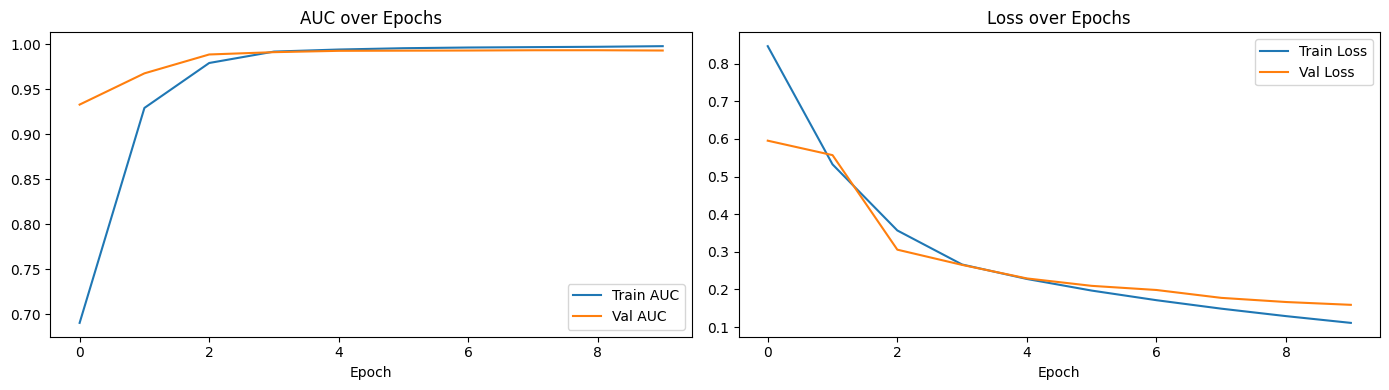

In [21]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['auc'],     label='Train AUC')
axes[0].plot(history.history['val_auc'], label='Val AUC')
axes[0].set_title('AUC over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


TP  : 4042  | FP  : 86
TN  : 4087  | FN  : 131
─────────────────────────────────────────────
FPR (Fake slipping as Real) : 2.06%
FNR (Real flagged as Fake)  : 3.14%
TNR / Specificity           : 97.94%
TPR / Sensitivity / Recall  : 96.86%


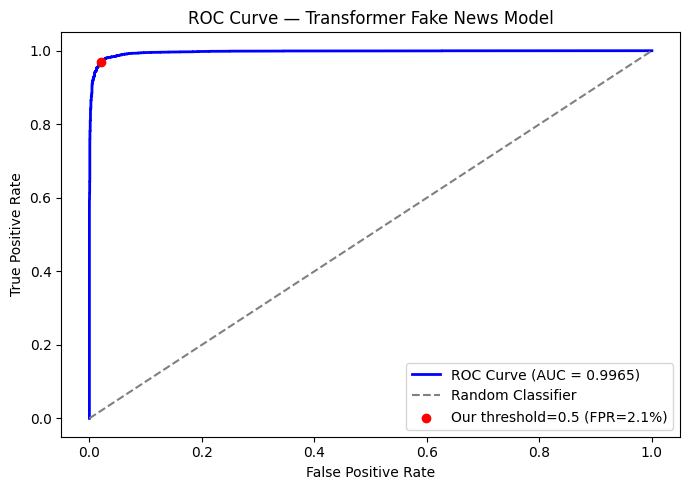

In [22]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ── Real-time calculation from model predictions ───────────────────────
y_pred_prob = model.predict(X_test_pad, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

# Confusion matrix — dynamic, not hardcoded
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Metrics
FPR = fp / (fp + tn)
FNR = fn / (fn + tp)
TNR = tn / (tn + fp)
TPR = tp / (tp + fn)  # Recall / Sensitivity

print(f"TP  : {tp}  | FP  : {fp}")
print(f"TN  : {tn}  | FN  : {fn}")
print(f"─" * 45)
print(f"FPR (Fake slipping as Real) : {FPR*100:.2f}%")
print(f"FNR (Real flagged as Fake)  : {FNR*100:.2f}%")
print(f"TNR / Specificity           : {TNR*100:.2f}%")
print(f"TPR / Sensitivity / Recall  : {TPR*100:.2f}%")

# ── ROC Curve — shows FPR vs TPR at every threshold ───────────────────
fpr_curve, tpr_curve, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr_curve, tpr_curve)

plt.figure(figsize=(7, 5))
plt.plot(fpr_curve, tpr_curve, color='blue', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.scatter([FPR], [TPR], color='red', zorder=5,
            label=f'Our threshold=0.5 (FPR={FPR*100:.1f}%)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Transformer Fake News Model')
plt.legend()
plt.tight_layout()
plt.show()

## 🔹 Prediction Function (same as Model 1)

In [23]:
def predict_headline(headline, threshold=0.5):
    """
    Predict whether a news headline is Fake or Real.
    label 0 = FAKE | label 1 = REAL
    sigmoid >= 0.5 → REAL | sigmoid < 0.5 → FAKE
    """
    cleaned = preprocess_text(headline)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob    = model.predict(padded, verbose=0)[0][0]

    label = 'REAL' if prob >= threshold else 'FAKE'
    conf  = prob if prob >= threshold else 1 - prob

    print(f'Headline : "{headline[:80]}"')
    print(f'Cleaned  : "{cleaned[:80]}"')
    print(f'Verdict  : {label}  (confidence: {conf*100:.1f}%)')
    bar_real = 'X' * int(prob * 30)
    bar_fake = 'X' * int((1 - prob) * 30)
    print(f'Real  {bar_real:<30} {prob*100:.1f}%')
    print(f'Fake  {bar_fake:<30} {(1-prob)*100:.1f}%')
    print()
    return label, float(prob)

# Test headlines
test_headlines = [
    'NASA confirms water ice found near Mars south pole',
    'Federal Reserve holds interest rates steady amid inflation concerns',
    'Scientists CONFIRM vaccines cause autism in new secret study',
    'President secretly signs bill to ban all social media by next week',
    'Aliens elected president of Mars yesterday',
    'Reuters reports that the stock market closed higher on Monday',
]

print('-' * 60)
for h in test_headlines:
    predict_headline(h)
    print('-' * 60)


------------------------------------------------------------
Headline : "NASA confirms water ice found near Mars south pole"
Cleaned  : "nasa confirm water ice find near mar south pole"
Verdict  : REAL  (confidence: 99.9%)
Real  XXXXXXXXXXXXXXXXXXXXXXXXXXXXX  99.9%
Fake                                 0.1%

------------------------------------------------------------
Headline : "Federal Reserve holds interest rates steady amid inflation concerns"
Cleaned  : "federal reserve hold interest rate steady amid inflation concern"
Verdict  : REAL  (confidence: 99.9%)
Real  XXXXXXXXXXXXXXXXXXXXXXXXXXXXX  99.9%
Fake                                 0.1%

------------------------------------------------------------
Headline : "Scientists CONFIRM vaccines cause autism in new secret study"
Cleaned  : "scientist confirm vaccine cause autism in new secret study"
Verdict  : REAL  (confidence: 99.9%)
Real  XXXXXXXXXXXXXXXXXXXXXXXXXXXXX  99.9%
Fake                                 0.1%

------------------

## 🔹 Save Model & Tokenizer

In [24]:
import pickle, json

# Save model
model.save('TransformerFakeNewsModel.h5')
print("✅ Model saved: TransformerFakeNewsModel.h5")

# Save tokenizer (same as Model 1 format)
with open('tokenizerTransformer.pickle', 'wb') as f:
    pickle.dump(tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)
print("✅ Tokenizer saved: tokenizerTransformer.pickle")

# Save MAX_LEN so test notebook never has to guess
with open('transformer_config.json', 'w') as f:
    json.dump({'MAX_LEN': int(MAX_LEN), 'vocab_size': vocab_size}, f)
print(f"✅ Config saved: transformer_config.json  (MAX_LEN={MAX_LEN})")


✅ Model saved: TransformerFakeNewsModel.h5
✅ Tokenizer saved: tokenizerTransformer.pickle
✅ Config saved: transformer_config.json  (MAX_LEN=1401)
